# 03 — SHAP analysis
Global and local explanations for the trained PD model artifact.


In [8]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.config import ARTIFACTS_DIR
from src.models.scoring.artifacts import ScoringArtifact
from src.models.scoring.explain import compute_shap_values, get_top_reasons

art = ScoringArtifact.load(ARTIFACTS_DIR)
print(art.model_type, art.metrics)

lightgbm {'val_auc_roc': 0.7700388216487781, 'val_auc_pr': 0.857360125517826, 'val_brier_score': 0.1866431233223966, 'val_log_loss': 0.5494121422170369, 'val_ks_statistic': 0.4051153231331354, 'val_gini': 0.5400776432975563, 'test_auc_roc': 0.7270172684458398, 'test_auc_pr': 0.805202040169606, 'test_brier_score': 0.2003506379892496, 'test_log_loss': 0.5892482266819896, 'test_ks_statistic': 0.3359026687598116, 'test_gini': 0.4540345368916796}


In [9]:
# Build a small synthetic matrix in feature space for SHAP demo
rng = np.random.default_rng(0)
X = pd.DataFrame({
    f: rng.normal(art.feature_medians.get(f, 0.0), 0.1, 200)
    for f in art.feature_names
})
shap_values, explainer = compute_shap_values(art.model, X)
shap_values.shape

2026-07-11 14:17:48.359 | INFO     | src.models.scoring.explain:compute_shap_values:38 - Computing SHAP values...
c:\Users\pc\anaconda1\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


(200, 23)

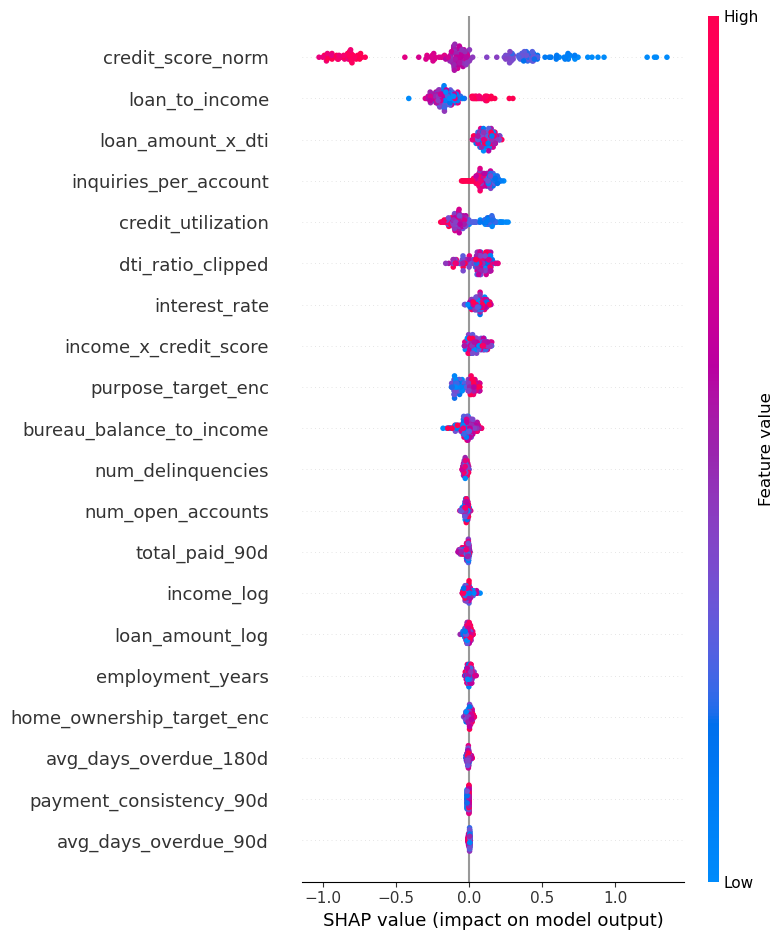

In [10]:
import shap
shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.show()

In [12]:
# Local reasons for first row
row = shap_values[0]
print(get_top_reasons(row, art.feature_names, top_n=5))

[{'feature': 'credit_score_norm', 'shap_value': 0.5992131964201945, 'direction': 'increases_risk'}, {'feature': 'loan_to_income', 'shap_value': -0.17948678503214419, 'direction': 'decreases_risk'}, {'feature': 'loan_amount_x_dti', 'shap_value': 0.15963445512199156, 'direction': 'increases_risk'}, {'feature': 'inquiries_per_account', 'shap_value': 0.13334216863992523, 'direction': 'increases_risk'}, {'feature': 'dti_ratio_clipped', 'shap_value': 0.1262245544560281, 'direction': 'increases_risk'}]
